# Task 4: Email/SMS Spam Detection with Machine Learning

## Objective
Build a machine learning model using Natural Language Processing (NLP) to classify messages as **Spam** or **Ham (Legitimate)**.

In [24]:
# Task 4: Email/SMS Spam Detection with Machine Learning

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [25]:
# Download the SMS Spam Collection dataset

!wget -q https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip
!unzip -o -q "sms+spam+collection.zip"

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [26]:
# Load the dataset

import pandas as pd

df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="latin-1"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [27]:
# Check dataset information

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["label"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing Values:
label      0
message    0
dtype: int64

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [28]:
# Calculate class percentages

class_counts = df["label"].value_counts()
class_percentages = df["label"].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages.round(2))

Class Counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Class Percentages:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


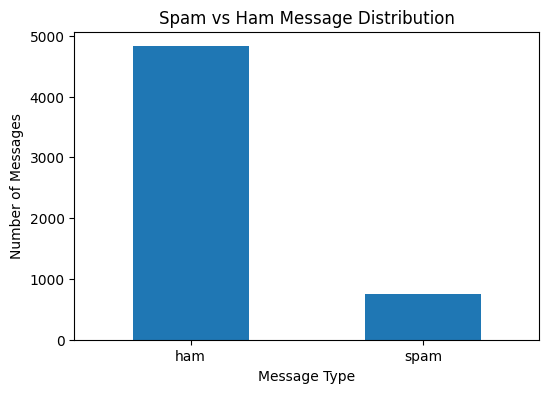

In [29]:
# Visualize spam vs ham distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar")
plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [30]:
# Import NLTK and download stopwords

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

print("NLTK setup completed!")

NLTK setup completed!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
# Text preprocessing function

import re

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()                         # Convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)     # Remove punctuation/numbers
    words = text.split()                        # Split into words
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return " ".join(words)

# Apply preprocessing
df["clean_message"] = df["message"].apply(preprocess_text)

# Display original and cleaned messages
df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that a machine-learning model can understand.

Term Frequency (TF): Measures how often a word appears in a message.
Inverse Document Frequency (IDF): Gives less importance to words that appear in many messages.
The final TF-IDF score represents how important a word is to a particular message.

TF-IDF helps identify words that are useful for distinguishing spam messages from legitimate messages.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer()

# Convert cleaned messages into numerical features
X = tfidf.fit_transform(df["clean_message"])

# Convert labels into numerical values
y = df["label"].map({"ham": 0, "spam": 1})

print("TF-IDF feature extraction completed!")
print("Feature matrix shape:", X.shape)

TF-IDF feature extraction completed!
Feature matrix shape: (5572, 8480)


In [33]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


In [34]:
from sklearn.naive_bayes import MultinomialNB

# Create the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [35]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluation function
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{model_name}")
    print("-" * 40)
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1-score :", round(f1_score(y_true, y_pred), 4))

# Evaluate both models
evaluate_model("Multinomial Naive Bayes", y_test, y_pred_nb)
evaluate_model("Logistic Regression", y_test, y_pred_lr)


Multinomial Naive Bayes
----------------------------------------
Accuracy : 0.9632
Precision: 1.0
Recall   : 0.7248
F1-score : 0.8405

Logistic Regression
----------------------------------------
Accuracy : 0.9587
Precision: 1.0
Recall   : 0.6913
F1-score : 0.8175


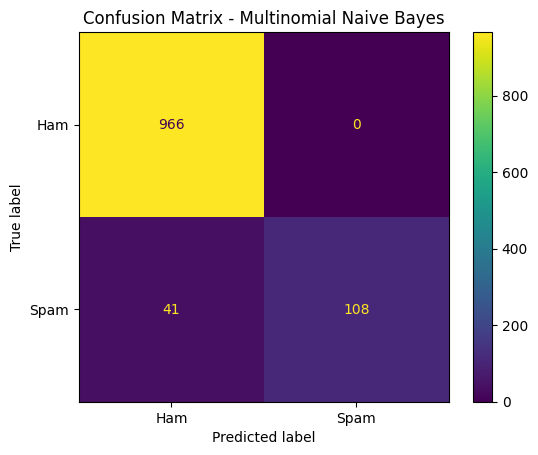

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Multinomial Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Ham", "Spam"]
)

disp_nb.plot()
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

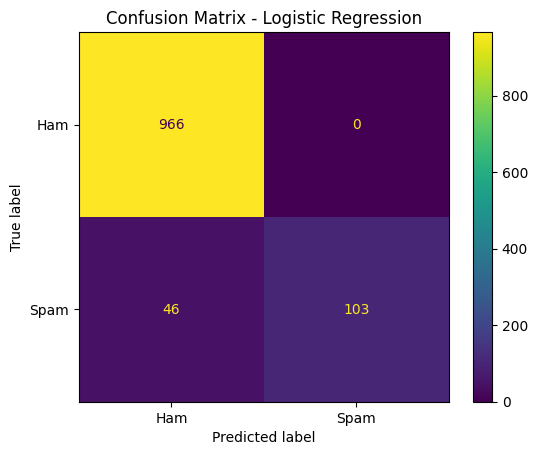

In [38]:

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Ham", "Spam"]
)

disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Why is Recall Important for Spam Detection?

Recall is particularly important in spam detection because it measures the percentage of actual spam messages that the model successfully identifies.

A low recall means that some spam messages are incorrectly classified as legitimate (ham). This can allow unwanted or potentially harmful messages to reach the user's inbox.

Therefore, a spam detection system should aim for high recall while also maintaining good precision, so that it catches most spam without incorrectly blocking legitimate messages.

In [39]:
# Create a comparison table for both models

results = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ],
    "Precision": [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr)
    ],
    "Recall": [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9632,1.0,0.7248,0.8405
1,Logistic Regression,0.9587,1.0,0.6913,0.8175


In [40]:
!pip install wordcloud -q

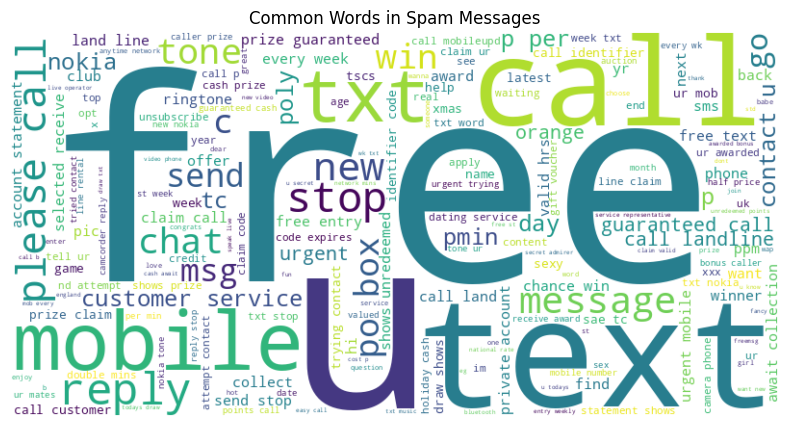

In [41]:
from wordcloud import WordCloud

# Combine spam messages
spam_text = " ".join(df[df["label"] == "spam"]["clean_message"])

# Combine ham messages
ham_text = " ".join(df[df["label"] == "ham"]["clean_message"])

# Generate spam word cloud
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Spam Messages")
plt.show()

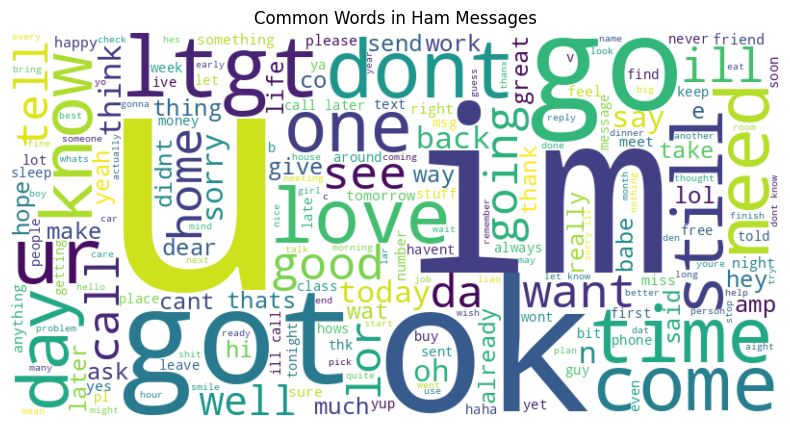

In [42]:
# Generate ham word cloud

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Ham Messages")
plt.show()

In [43]:
# Test the spam detection model with a new message

new_message = input("Enter a message to classify: ")

# Preprocess the new message
clean_new_message = preprocess_text(new_message)

# Convert the message using the trained TF-IDF vectorizer
new_message_tfidf = tfidf.transform([clean_new_message])

# Predict using Logistic Regression
prediction = lr_model.predict(new_message_tfidf)[0]

if prediction == 1:
    print("\nPrediction: SPAM")
else:
    print("\nPrediction: HAM (Legitimate)")

Enter a message to classify: hey how are you

Prediction: HAM (Legitimate)



### Conclusion

In this project, a Natural Language Processing-based machine learning system was developed to classify messages as spam or legitimate (ham).

The SMS Spam Collection dataset was cleaned using lowercase conversion, punctuation removal, and stopword removal. TF-IDF was then used to convert the text messages into numerical features.

Two machine learning algorithms, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated using accuracy, precision, recall, and F1-score. Confusion matrices were also used to analyze the classification results.

Recall is particularly important in spam detection because a low recall means that actual spam messages may be incorrectly classified as legitimate messages.

Overall, the project demonstrates how NLP and machine learning can be combined to create an effective spam detection system.